# Mount Drive and Extract the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Extract the zip file to Colab's fast local storage
zip_path = '/content/drive/MyDrive/AI/animal-image-dataset-90-different-animals.zip'
extract_path = '/content/AI/Animal_Classification_Project'

In [ ]:
import zipfile
import os

print("Extracting dataset...")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

Extracting dataset...
Extraction complete!


# Visualisation

Detected actual animal classes root directory: /content/AI/Animal_Classification_Project/animals/animals
Generating Sample Images Grid...


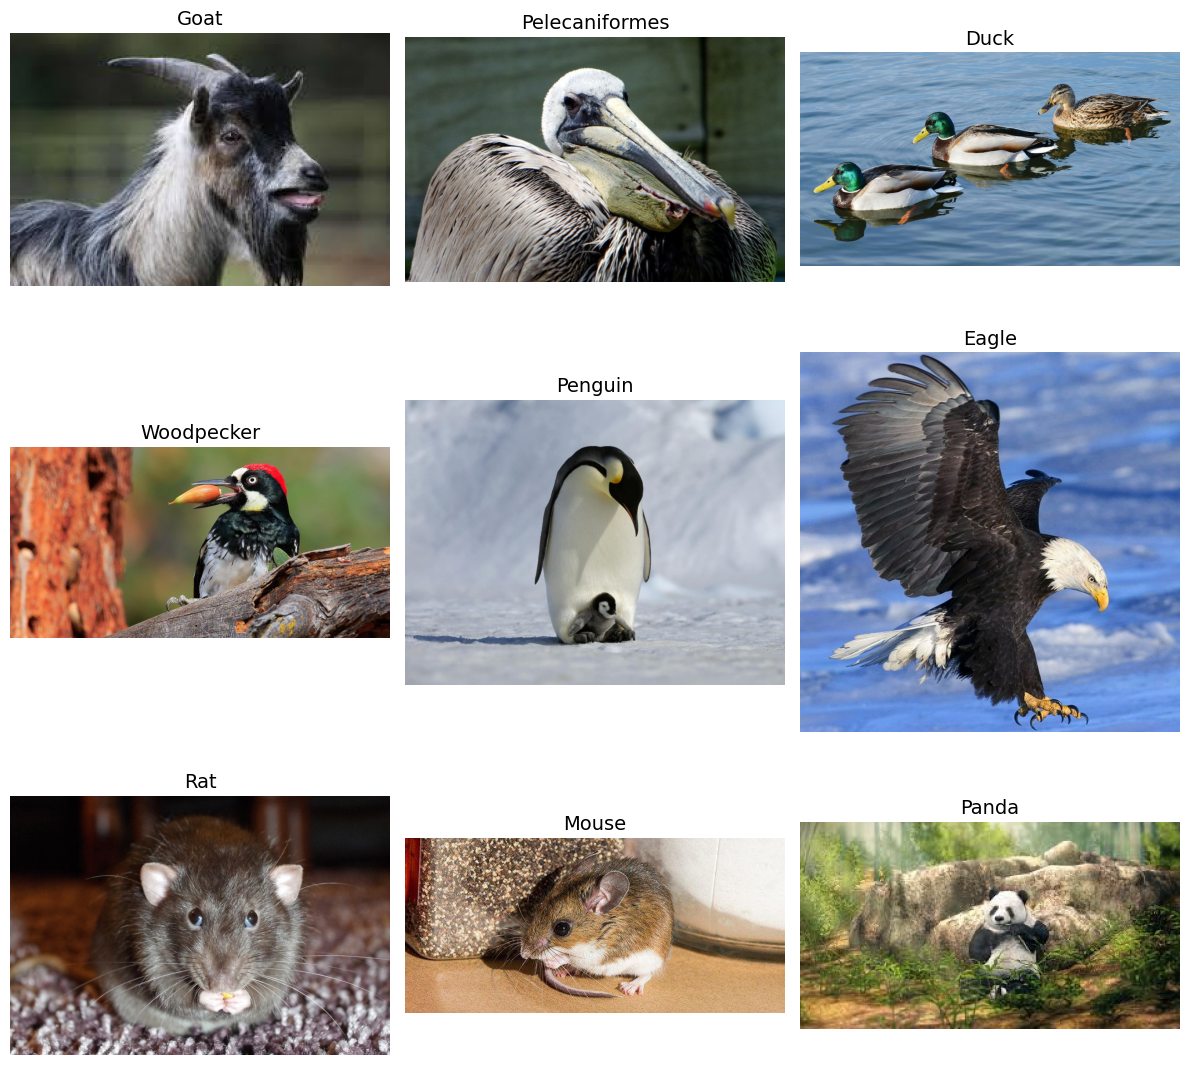


Generating Class Distribution Chart...


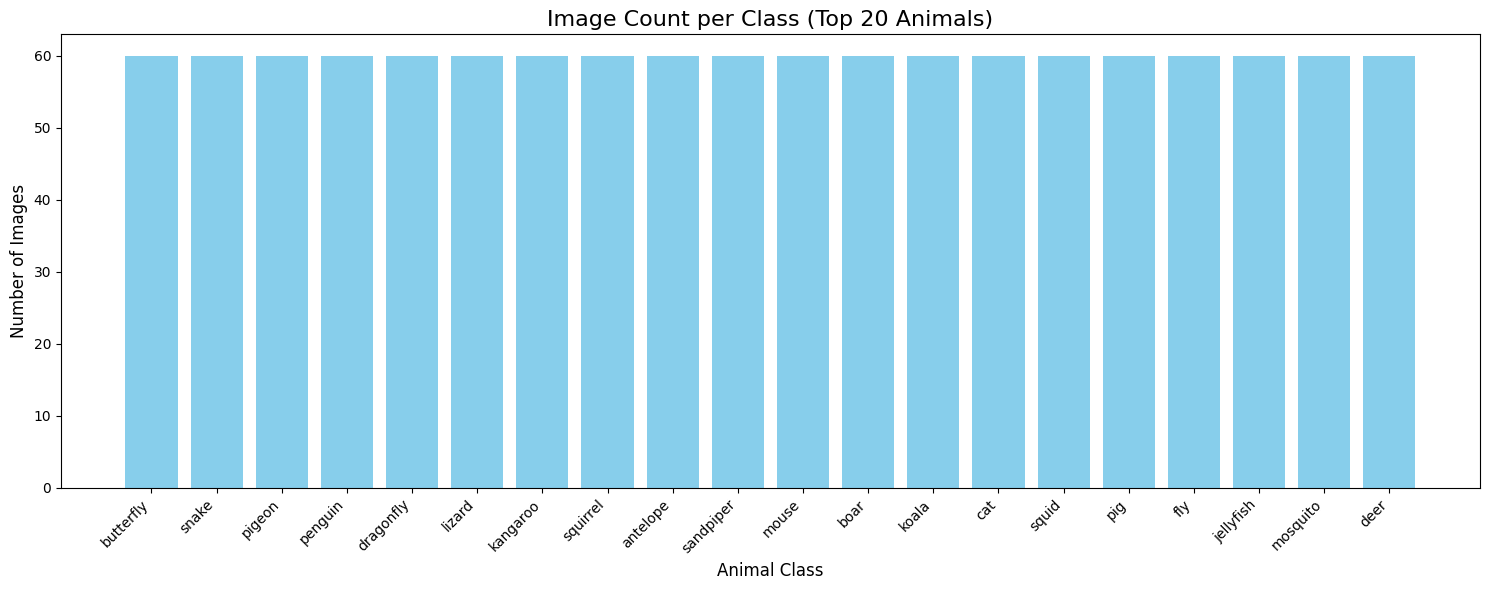

Analysing image dimensions (this might take a few seconds)...


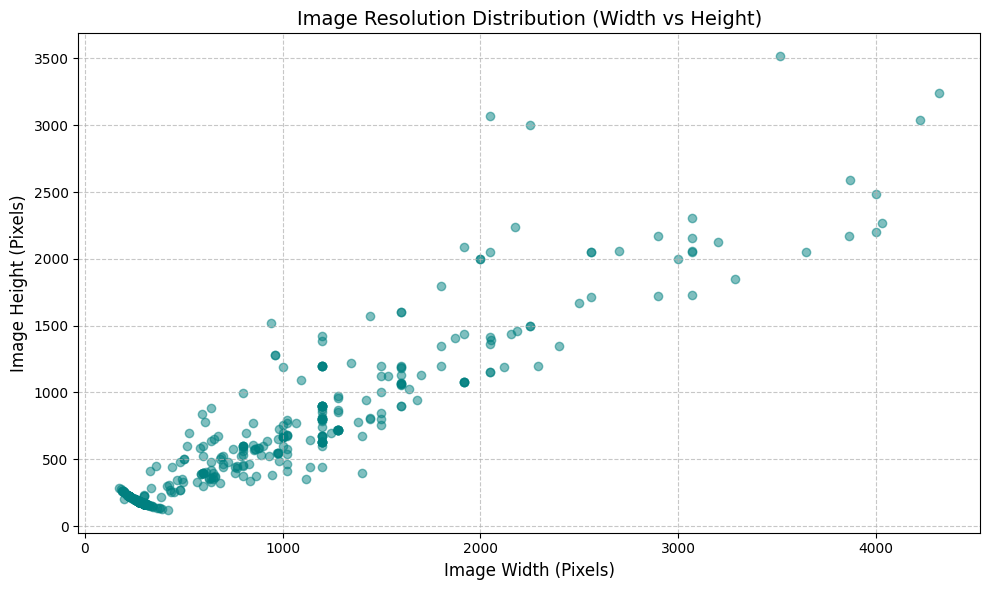


Calculating Average RGB Color Distribution...


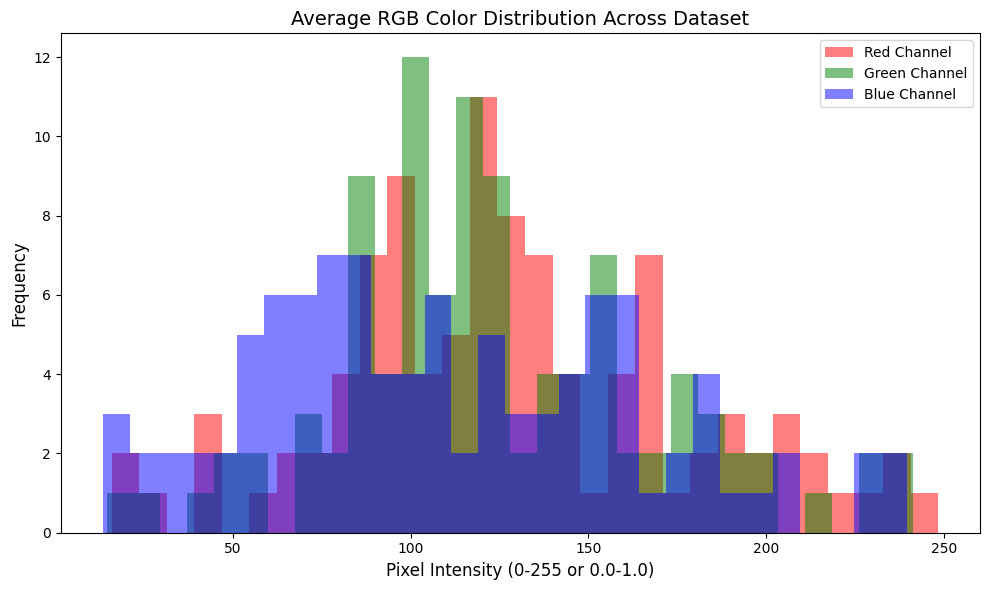

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image

#Point this to your extracted dataset folder
initial_source_dir = '/content/AI/Animal_Classification_Project'
source_dir = initial_source_dir


# Keep track of the best candidate for source_dir based on number of subdirectories
best_candidate_dir = initial_source_dir
max_subdirs = 0

# Explore a few levels deep (e.g., 3 levels) to find the best candidate for the actual class directory
current_path = initial_source_dir
for _ in range(3): # Limit depth of search to prevent infinite loops or too long search
    if not os.path.isdir(current_path):
        break

    contents = os.listdir(current_path)
    subdirectories = [d for d in contents if os.path.isdir(os.path.join(current_path, d))]

    # Count actual class-like directories 
    actual_class_dirs = [d for d in subdirectories if d.lower() != 'animals']

    if len(actual_class_dirs) > max_subdirs:
        max_subdirs = len(actual_class_dirs)
        best_candidate_dir = current_path

    # If an 'animals' subdirectory exists, consider descending into it
    if 'animals' in subdirectories and os.path.isdir(os.path.join(current_path, 'animals')):
        animals_path = os.path.join(current_path, 'animals')
        animals_contents = os.listdir(animals_path)
        animals_subdirs = [d for d in animals_contents if os.path.isdir(os.path.join(animals_path, d))]

        # If the 'animals' folder itself contains more subdirectories than the current best candidate,
        # then it's likely the true root of class folders.
        if len(animals_subdirs) > max_subdirs:
            max_subdirs = len(animals_subdirs)
            best_candidate_dir = animals_path

        current_path = animals_path # Always descend if 'animals' is a valid path to explore
    else:
        break # No 'animals' subdirectory or it's not a directory, assume current_path is the one.

source_dir = best_candidate_dir
print(f"Detected actual animal classes root directory: {source_dir}")

# 1. VISUALISATION: Sample Images Grid
print("Generating Sample Images Grid...")
plt.figure(figsize=(12, 12))

# Filter out non-directory items from the actual class directory
animal_classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# Pick 9 random animals to display
num_samples = min(9, len(animal_classes))

if num_samples == 0:
    print(f"Warning: No animal class directories found in {source_dir}. Skipping image grid generation.")
else:
    sample_classes = random.sample(animal_classes, num_samples)

    for i, animal in enumerate(sample_classes):
        animal_path = os.path.join(source_dir, animal)
        # Get the first image in that animal's folder
        # Ensure the directory is not empty and contains actual files
        images_in_class = [f for f in os.listdir(animal_path) if os.path.isfile(os.path.join(animal_path, f))]
        if not images_in_class:
            print(f"Warning: No images found in class directory: {animal_path}. Skipping.")
            continue
        sample_image = images_in_class[0]
        img = mpimg.imread(os.path.join(animal_path, sample_image))

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(animal.capitalize(), fontsize=14)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# 2. VISUALISATION: Class Distribution (Bar Chart)
print("\nGenerating Class Distribution Chart...")
class_counts = {}

for animal in animal_classes:
    animal_path = os.path.join(source_dir, animal)
    if os.path.isdir(animal_path):
        class_counts[animal] = len(os.listdir(animal_path))

# Sort the data for a cleaner chart (top 20 and bottom 20 so it fits nicely)
sorted_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6))
plt.bar(list(sorted_counts.keys())[:20], list(sorted_counts.values())[:20], color='skyblue')
plt.title('Image Count per Class (Top 20 Animals)', fontsize=16)
plt.xlabel('Animal Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#3.Visualisation: Resolution & Aspect Ratio Scatter Plot
print("Analysing image dimensions (this might take a few seconds)...")
widths = []
heights = []

# Sample 500 random images to keep processing fast
all_images = []
for animal in animal_classes:
    animal_path = os.path.join(source_dir, animal)
    if os.path.isdir(animal_path):
        for img_name in os.listdir(animal_path):
            # Ensure it's a file before adding to all_images
            if os.path.isfile(os.path.join(animal_path, img_name)):
                all_images.append(os.path.join(animal_path, img_name))

sample_images = random.sample(all_images, min(500, len(all_images)))

for img_path in sample_images:
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)
    except:
        pass # Skip broken images

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.5, color='teal')
plt.title('Image Resolution Distribution (Width vs Height)', fontsize=14)
plt.xlabel('Image Width (Pixels)', fontsize=12)
plt.ylabel('Image Height (Pixels)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 4.Visualisation: Average RGB Color Distribution

print("\nCalculating Average RGB Color Distribution...")
r_means, g_means, b_means = [], [], []

# Sample 100 images for color analysis
color_sample = random.sample(all_images, min(100, len(all_images)))

for img_path in color_sample:
    try:
        img = mpimg.imread(img_path)
        if len(img.shape) == 3:
            r_means.append(np.mean(img[:,:,0]))
            g_means.append(np.mean(img[:,:,1]))
            b_means.append(np.mean(img[:,:,2]))
    except:
        pass

plt.figure(figsize=(10, 6))
plt.hist(r_means, bins=30, color='red', alpha=0.5, label='Red Channel')
plt.hist(g_means, bins=30, color='green', alpha=0.5, label='Green Channel')
plt.hist(b_means, bins=30, color='blue', alpha=0.5, label='Blue Channel')
plt.title('Average RGB Color Distribution Across Dataset', fontsize=14)
plt.xlabel('Pixel Intensity (0-255 or 0.0-1.0)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()